# Winner / Loser Explorer

Combines the backtest run (from `backtest_005d`) with the feature-discrimination
analysis (from `t_loser_autopsy`) into a single focused notebook.

**Workflow:**
1. Run Section 1 once to generate / re-generate `all_trades_with_features.h5`
2. Jump straight to Section 2 for feature exploration (skip Section 1 if the h5 already exists)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numba as nb
import vectorbt as vbt
import talib

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 100
print('imports ok')


imports ok


## Section 1 — Generate Trades

> **Skip this section** if `all_trades_with_features.h5` already exists in this directory.
> Jump to **Section 2** to load it and start exploring.


In [2]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)
    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake ...')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

BENCHMARK_SYM = 'VNINDEX'
if BENCHMARK_SYM in close.columns:
    close_benchmark = close[BENCHMARK_SYM]
else:
    close_benchmark = close.mean(axis=1)
    print(f'Note: {BENCHMARK_SYM!r} not in panel — using cross-sectional mean')

print(f'Shape: {close.shape}  |  {close.index[0]} -> {close.index[-1]}')
close.tail(3)


Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-06-06 00:00:00 -> 2026-06-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-01,7.03,15.6,24.9,43.7,9.06,12.00,14.55,21.6,5.55,5.86,...,1844.54,59.1,12.4,26.95,3.14,62.9,31.20,19.85,65.3,8.83
2026-06-02,6.98,15.8,25.1,43.4,9.06,11.95,14.30,21.1,5.47,5.86,...,1826.47,58.6,12.2,26.45,3.04,61.9,31.00,19.25,65.7,9.04
2026-06-03,7.00,15.9,26.0,43.7,9.05,11.95,14.30,21.3,5.46,5.99,...,1819.01,58.3,12.3,26.45,3.01,60.5,30.05,19.65,65.8,9.01


In [3]:
@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')


Numba helpers compiled


In [6]:

AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP', short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)

_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(
            close, high, low, volume,
            is_highest=[False],
            window=int(window),
        ).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume, close_benchmark,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3', ttm_cross_bars=0, consecutive_neg_threshold=7,
    william_vix_period=20,
    use_avwap_filter=True, avwap_window=200,
    use_kama_slope=True, kama_period=10, kama_fast=2, kama_slow=30,
    kama_slope_win=5, flat_threshold_pct=1.0,
):
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np = bb.upperband.to_numpy()
    bb_lower_np = bb.lowerband.to_numpy()
    ema_np      = ema.real.to_numpy()
    atr_np      = atr.real.to_numpy()
    kc_upper_np = ema_np + kc_multiplier * atr_np
    kc_lower_np = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    if use_avwap_filter:
        avwap_lowest    = get_avwap_lowest(close, high, low, volume, avwap_window)
        avwap_prev_np   = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
        avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    else:
        avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    distance_ma50_np = (close_np / close.rolling(50).mean() - 1)
    distance_ma20_np = (close_np / close.rolling(20).mean() - 1)  #  REQUIRE dist_ma20 <= 0.05924  → cat rate: 23.7% inside risk zone  vs 8.5% outside  (lift 2.37x, n=865)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        if ttm_cross_bars == 0:
            signal_np = ttms_np > 0
        else:
            shifted = [shift_2d(ttms_np, i) for i in range(ttm_cross_bars + 2)]
            conds = []
            for lag in range(ttm_cross_bars + 1):
                cross = (shifted[lag + 1] < 0) & (shifted[lag] > 0)
                if lag > 0:
                    cross = cross & (ttms_np > shifted[lag])
                conds.append(cross)
            signal_np = np.logical_or.reduce(conds)
        entries_np = no_sqz_np & signal_np & flat_np & ((distance_ma50_np <= 0.15) & (distance_ma20_np <= 0.08))
    else:  # v3 — Williams VIX Fix contrarian
        entries_np = wvf_np

    entries_np = entries_np & avwap_filter_np
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=3):
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)
    MIN      = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)
    return exits_df, sl_stop_df


def compute_avwap_sl_exits(close, high, low, volume,
                            avwap_window: int = 200, min_anchor_bars: int = 10):
    avwap_df    = get_avwap_lowest(close, high, low, volume, avwap_window)
    anchor_bars = close.rolling(avwap_window).apply(
        lambda x: len(x) - 1 - int(np.argmin(x)), raw=True
    )
    cross_below = (close < avwap_df) & (close.shift(1) >= avwap_df.shift(1))
    return cross_below & (anchor_bars >= min_anchor_bars)


print('Signal functions defined')


Signal functions defined


In [8]:
# Fixed v1 params — edit here if you want to explore different settings
PARAMS = dict(
    bb_window=16, bb_multiplier=1.0, bb_matype=3,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v1',
    ttm_cross_bars=0,
    consecutive_neg_threshold=7,
    william_vix_period=20,
    use_avwap_filter=True, avwap_window=200,
    use_kama_slope=True, kama_period=10, kama_fast=2, kama_slow=30,
    kama_slope_win=5, flat_threshold_pct=1.0,
)

print('Computing entries ...')
entries = compute_signals(close, high, low, volume, close_benchmark, **PARAMS)
print(f'Entry signals: {entries.sum().sum():,}')

exits, sl_stop = compute_exits(close, high, low, atr_multiplier=1.9)
exits = exits | compute_avwap_sl_exits(close, high, low, volume,
                                        avwap_window=200, min_anchor_bars=10)

pf = vbt.Portfolio.from_signals(
    close=close, entries=entries, exits=exits, sl_stop=sl_stop,
    freq='1d', group_by=['symbol'],
)

# ── Build features + export ───────────────────────────────────────────────
W = 20
tr = pf.trades.records_readable.copy()
close_syms_set = set(close.columns)

def _sym(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms_set), str(col))
    return col if isinstance(col, str) and col in close_syms_set else str(col)

tr['symbol']     = tr['Column'].apply(_sym)
tr['entry_date'] = pd.to_datetime(tr['Entry Timestamp']).dt.normalize()
tr['exit_date']  = pd.to_datetime(tr['Exit Timestamp']).dt.normalize()
if 'Return [%]' in tr.columns:
    tr['net_return'] = tr['Return [%]'] / 100
elif 'Return' in tr.columns:
    tr['net_return'] = pd.to_numeric(tr['Return'], errors='coerce')
else:
    raise KeyError(f'No return column; got {list(tr.columns)}')
tr['Y'] = (tr['net_return'] > 0).astype(int)

def _col(df, *names):
    for n in names:
        if n in df.columns:
            return df[n]
    raise KeyError(f'None of {names} in {list(df.columns)}')

# also save integer bar positions — used for reliable MFE/MAE path lookup
base = tr[['symbol', 'entry_date', 'exit_date', 'net_return', 'Y', 'Size', 'PnL']].copy()
base['Entry Price'] = _col(tr, 'Entry Price', 'Avg Entry Price')
base['Exit Price']  = _col(tr, 'Exit Price', 'Avg Exit Price')

_price_index = pd.DatetimeIndex(close.index).normalize()

def _ts_to_i(ts):
    ts = pd.Timestamp(ts).normalize()
    try:
        loc = _price_index.get_loc(ts)
    except KeyError:
        loc = _price_index.get_indexer([ts], method='nearest')[0]
        return int(loc)
    if isinstance(loc, slice):
        return loc.start
    if isinstance(loc, np.ndarray):
        return int(loc[0])
    return int(loc)

if 'Entry Index' in tr.columns:
    base['entry_bar'] = tr['Entry Index'].astype(int)
    base['exit_bar']  = tr['Exit Index'].astype(int)
elif 'Entry Bar' in tr.columns:
    base['entry_bar'] = tr['Entry Bar'].astype(int)
    base['exit_bar']  = tr['Exit Bar'].astype(int)
else:
    base['entry_bar'] = tr['Entry Timestamp'].map(_ts_to_i).astype(int)
    base['exit_bar']  = tr['Exit Timestamp'].map(_ts_to_i).astype(int)

log_ret        = np.log(close / close.shift(1))
roll_vol       = log_ret.rolling(W).std() * np.sqrt(252)
vol_ratio      = volume / volume.rolling(W).mean()
ma50           = close.rolling(50).mean()
ma200          = close.rolling(200).mean()
momentum       = close.pct_change(W)
atr_abs        = vbt.IndicatorFactory.from_talib('ATR').run(high, low, close, timeperiod=W).real
atr_pct        = atr_abs / close
rsi14          = vbt.IndicatorFactory.from_talib('RSI').run(close, timeperiod=14).real
price_vs_ma50  = close / ma50  - 1
price_vs_ma200 = close / ma200 - 1
vn_mom         = close_benchmark.pct_change(W).rename('vn_momentum_20')

MRS_WINDOW = 21
rsd        = close.div(close_benchmark, axis=0) * 100
ma_rsd     = rsd.rolling(MRS_WINDOW).mean()
mrs        = (rsd / ma_rsd - 1) * 100
mrs        = mrs.replace([np.inf, -np.inf], np.nan)

AVWAP_W     = 200
_avwap_lo   = AVWAP.run(close, high, low, volume, is_highest=[False], window=AVWAP_W).avwap
_avwap_lo   = _avwap_lo.xs(False, level='avwap_is_highest', axis=1)
_avwap_lo.columns = _avwap_lo.columns.get_level_values(-1)
_avwap_lo   = _avwap_lo.reindex(columns=close.columns)
_avwap_hi   = AVWAP.run(close, high, low, volume, is_highest=[True],  window=AVWAP_W).avwap
_avwap_hi   = _avwap_hi.xs(True,  level='avwap_is_highest', axis=1)
_avwap_hi.columns = _avwap_hi.columns.get_level_values(-1)
_avwap_hi   = _avwap_hi.reindex(columns=close.columns)
ma20        = close.rolling(20).mean()
dist_avwap_lo = (close / _avwap_lo  - 1).replace([np.inf, -np.inf], np.nan)
dist_avwap_hi = (close / _avwap_hi  - 1).replace([np.inf, -np.inf], np.nan)
dist_ma20     = (close / ma20       - 1).replace([np.inf, -np.inf], np.nan)

feat_panels = {
    'roll_vol_20':    roll_vol,
    'vol_ratio':      vol_ratio,
    'price_vs_ma50':  price_vs_ma50,
    'price_vs_ma200': price_vs_ma200,
    'momentum_20':    momentum,
    'atr_pct':        atr_pct,
    'rsi14':          rsi14,
    'mrs_21':         mrs,
    'dist_avwap_lo':  dist_avwap_lo,
    'dist_avwap_hi':  dist_avwap_hi,
    'dist_ma20':      dist_ma20,
}

def panel_to_long(panel_df, col_name):
    panel = panel_df.copy()
    if isinstance(panel.columns, pd.MultiIndex):
        panel.columns = panel.columns.get_level_values(-1)
    panel.index.name = 'entry_date'
    return panel.reset_index().melt(
        id_vars='entry_date', var_name='symbol', value_name=col_name,
    )

feat_df = base[['entry_date', 'symbol']].copy()
for col_name, panel in feat_panels.items():
    feat_df = feat_df.merge(panel_to_long(panel, col_name),
                            on=['entry_date', 'symbol'], how='left')

vn_long = vn_mom.reset_index().rename(columns={'date': 'entry_date'})
feat_df = feat_df.merge(vn_long, on='entry_date', how='left')

all_trades_with_features = pd.concat(
    [base.reset_index(drop=True),
     feat_df.drop(columns=['entry_date', 'symbol']).reset_index(drop=True)],
    axis=1,
)

out_path = 'all_trades_with_features.h5'
all_trades_with_features.to_hdf(out_path, key='data', mode='w', complevel=5)

print(f'Saved -> {out_path}')
print(f'  trades   : {len(all_trades_with_features):,}')
print(f'  win rate : {all_trades_with_features["Y"].mean():.1%}')
print(f'  date range: {all_trades_with_features["entry_date"].min().date()} -> {all_trades_with_features["entry_date"].max().date()}')
all_trades_with_features.head(3)


Computing entries ...
Entry signals: 26,952
Saved -> all_trades_with_features.h5
  trades   : 8,688
  win rate : 32.3%
  date range: 2017-03-22 -> 2026-06-03


,symbol,entry_date,exit_date,net_return,Y,Size,PnL,Entry Price,Exit Price,entry_bar,...,price_vs_ma50,price_vs_ma200,momentum_20,atr_pct,rsi14,mrs_21,dist_avwap_lo,dist_avwap_hi,dist_ma20,vn_momentum_20
0,AAA,2017-04-28,2017-05-16,0.116312,1,7.092199,11.631206,14.10,15.74,226,...,0.035729,-0.033611,0.059354,0.026139,60.588294,2.994442,0.046062,0.009281,0.026425,-0.008468
1,AAA,2017-08-16,2017-08-22,-0.054816,0,5.940990,-6.119220,18.79,17.76,302,...,0.038408,0.243025,0.061582,0.027077,61.784860,5.620112,0.182880,0.021386,0.051718,0.002943
2,AAA,2017-10-12,2017-10-20,-0.018721,0,5.486843,-1.975263,19.23,18.87,342,...,0.037709,0.203375,0.002607,0.023740,55.006792,-0.860961,0.161209,0.004259,0.002999,0.011844


In [12]:
all_trades_with_features_filter = all_trades_with_features[all_trades_with_features['symbol'] == 'VCG']
all_trades_with_features_filter.tail(10)

,symbol,entry_date,exit_date,net_return,Y,Size,PnL,Entry Price,Exit Price,entry_bar,...,price_vs_ma50,price_vs_ma200,momentum_20,atr_pct,rsi14,mrs_21,dist_avwap_lo,dist_avwap_hi,dist_ma20,vn_momentum_20
7469,VCG,2025-03-31,2025-04-03,-0.073560,0,4.631509,-6.623057,19.44,18.01,2207,...,0.039028,0.148763,0.000000,0.024243,59.620117,3.303275,0.106508,0.021425,0.021142,-0.001917
7470,VCG,2025-04-16,2025-07-29,0.231269,1,4.166507,19.290928,20.02,24.65,2218,...,0.057044,0.178226,0.092795,0.036913,59.672230,12.061492,0.129497,0.004516,0.071075,-0.090663
7471,VCG,2025-09-12,2025-09-23,-0.014842,0,3.810924,-1.524370,26.95,26.55,2320,...,0.074133,0.334796,0.005597,0.034979,60.623843,3.034624,0.241658,0.032351,0.039637,0.034537
7472,VCG,2025-09-30,2025-10-20,-0.070397,0,3.652709,-7.122782,27.70,25.75,2332,...,0.059233,0.326092,0.090551,0.036668,57.375310,3.529294,0.250021,0.002480,0.032523,-0.012192
7473,VCG,2025-11-20,2025-11-24,-0.006224,0,3.902790,-0.585419,24.10,23.95,2369,...,-0.082184,0.065596,-0.060429,0.033525,40.109391,-3.165995,0.004046,-0.101619,-0.023896,-0.018417
7474,VCG,2025-11-26,2025-11-28,-0.022634,0,3.846577,-2.115618,24.30,23.75,2373,...,-0.064701,0.068968,-0.074286,0.031407,44.727932,-2.715521,0.012367,-0.091274,-0.001746,-0.003245
7475,VCG,2025-12-08,2025-12-12,-0.053279,0,3.744107,-4.867339,24.40,23.10,2381,...,-0.041860,0.064426,0.042735,0.027659,48.814215,-3.457174,0.016441,-0.082063,0.011713,0.109583
7476,VCG,2026-02-24,2026-03-02,-0.026042,0,4.504629,-2.252314,19.20,18.70,2430,...,-0.119428,-0.185908,-0.175966,0.033590,37.414133,-5.425435,0.027786,-0.222842,-0.023398,-0.013814
7477,VCG,2026-04-10,2026-04-16,-0.037199,0,3.686501,-3.133526,22.85,22.00,2463,...,0.113168,-0.038290,-0.027660,0.044044,58.430211,-0.653558,0.065278,-0.036340,0.035811,0.031694
7478,VCG,2026-05-06,2026-05-08,-0.049569,0,3.495820,-4.020193,23.20,22.05,2478,...,0.076916,-0.023261,0.084112,0.037241,58.910435,-0.961309,0.068396,-0.016959,0.037915,0.123014


---

## Section 2 — Feature Analysis

All cells below only need `all_trades_with_features.h5`.  
You can run these without re-running Section 1.


In [ ]:
training_df = pd.read_hdf('all_trades_with_features.h5', 'data')

required_cols = ['symbol', 'entry_date', 'exit_date', 'net_return', 'Y']
assert all(c in training_df.columns for c in required_cols), \
    f'Missing columns. Need: {required_cols}'

print(f'Total trades : {len(training_df)}')
print(f'Date range   : {training_df["entry_date"].min()} -> {training_df["entry_date"].max()}')
print(f'Symbols      : {training_df["symbol"].nunique()}')
print(f'Win rate     : {training_df["Y"].mean():.2%}')
print(f'Mean return  : {training_df["net_return"].mean():.3%}')
training_df.head(3)


Total trades : 8455
Date range   : 1970-01-18 05:13:55.200000 -> 1970-01-21 13:52:19.200000
Symbols      : 195
Win rate     : 33.03%
Mean return  : 2.245%


,symbol,entry_date,exit_date,net_return,Y,Size,PnL,Entry Price,Exit Price,roll_vol_20,...,price_vs_ma50,price_vs_ma200,momentum_20,atr_pct,rsi14,mrs_21,dist_avwap_lo,dist_avwap_hi,dist_ma20,vn_momentum_20
0,AAA,1970-01-18 06:48:57.600,1970-01-18 07:14:52.800,0.116312,1,7.092199,11.631206,14.10,15.74,0.260199,...,0.035729,-0.033611,0.059354,0.026139,60.588293,2.994442,0.046062,0.009281,0.026425,-0.008468
1,AAA,1970-01-18 09:27:21.600,1970-01-18 09:36:00.000,-0.054816,0,5.940990,-6.119220,18.79,17.76,0.280963,...,0.038408,0.243025,0.061582,0.027077,61.784860,5.620112,0.182880,0.021386,0.051718,0.002943
2,AAA,1970-01-18 10:49:26.400,1970-01-18 11:00:57.600,-0.018721,0,5.486843,-1.975263,19.23,18.87,0.216044,...,0.037709,0.203375,0.002607,0.023740,55.006792,-0.860961,0.161209,0.004259,0.002999,0.011844


### 2.1 Segmentation

Quantile thresholds: 10%=-5.619%, 30%=-2.949%, 70%=0.917%, 90%=13.544%

                     count  mean_return  median_return
outcome                                               
1_catastrophic_loss    846      -0.0752        -0.0697
2_medium_loss         1691      -0.0411        -0.0403
3_marginal            3381      -0.0127        -0.0132
4_medium_win          1691       0.0561         0.0502
5_big_win              846       0.3203         0.2391


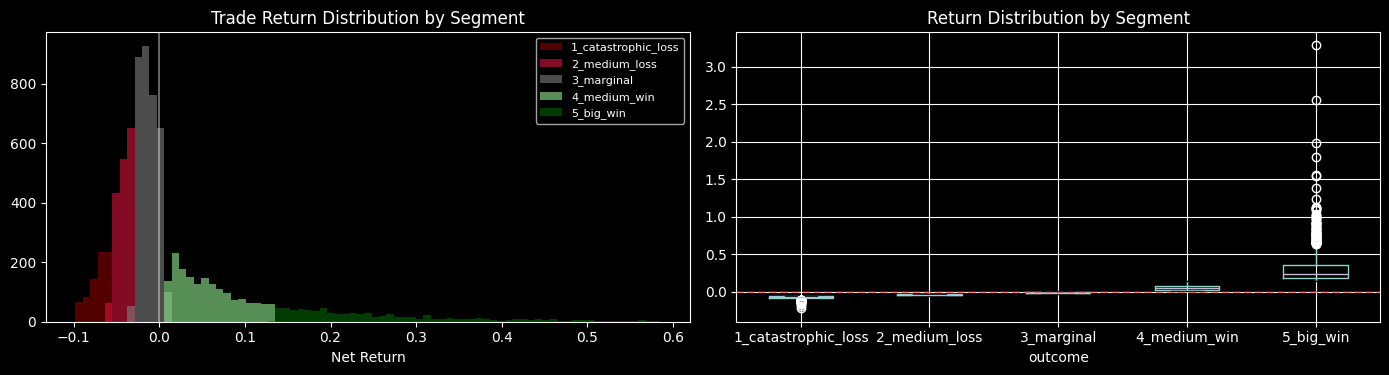

Losers: 2537 | Winners: 2537 | Catastrophic: 846


In [ ]:
def segment_trades(df):
    df = df.copy()
    q = df['net_return'].quantile([0.10, 0.30, 0.70, 0.90]).values
    def categorize(r):
        if   r <= q[0]: return '1_catastrophic_loss'
        elif r <= q[1]: return '2_medium_loss'
        elif r <= q[2]: return '3_marginal'
        elif r <= q[3]: return '4_medium_win'
        else:           return '5_big_win'
    df['outcome'] = df['net_return'].apply(categorize)
    return df, q


training_df, return_quantiles = segment_trades(training_df)
print(f'Quantile thresholds: 10%={return_quantiles[0]:.3%}, '
      f'30%={return_quantiles[1]:.3%}, 70%={return_quantiles[2]:.3%}, '
      f'90%={return_quantiles[3]:.3%}')
print()
print(training_df.groupby('outcome').agg(
    count=('net_return', 'count'),
    mean_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.linspace(training_df['net_return'].quantile(0.01),
                   training_df['net_return'].quantile(0.99), 80)
colors = {'1_catastrophic_loss': '#8B0000',
          '2_medium_loss':       '#DC143C',
          '3_marginal':          '#808080',
          '4_medium_win':        '#90EE90',
          '5_big_win':           '#006400'}
for outcome, color in colors.items():
    subset = training_df[training_df['outcome'] == outcome]['net_return']
    axes[0].hist(subset, bins=bins, alpha=0.6, label=outcome, color=color)
axes[0].axvline(0, color='white', alpha=0.4)
axes[0].set_xlabel('Net Return')
axes[0].set_title('Trade Return Distribution by Segment')
axes[0].legend(fontsize=8)
training_df.boxplot(column='net_return', by='outcome', ax=axes[1],
                    showfliers=True, patch_artist=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Return Distribution by Segment')
plt.suptitle('')
plt.tight_layout()
plt.show()

losers  = training_df[training_df['outcome'].isin(['1_catastrophic_loss', '2_medium_loss'])].copy()
winners = training_df[training_df['outcome'].isin(['4_medium_win', '5_big_win'])].copy()
catastrophic = training_df[training_df['outcome'] == '1_catastrophic_loss'].copy()
print(f'Losers: {len(losers)} | Winners: {len(winners)} | Catastrophic: {len(catastrophic)}')


### 2.2 Univariate Feature Discrimination

In [ ]:
exclude_cols = {
    'symbol', 'entry_date', 'exit_date', 'date', 'col', 'entry_idx', 'exit_idx',
    'return', 'net_return', 'Y', 'outcome', 'metadata', 'type',
    'Entry Price', 'Exit Price', 'Size', 'PnL', 'status', 'index',
    'open', 'high', 'low', 'close', 'volume', 'direction', 'parent_id', 'id',
}
feature_cols = [
    c for c in training_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(training_df[c])
    and training_df[c].nunique() > 5
]
print(f'Analyzing {len(feature_cols)} numeric features: {feature_cols}')


def feature_discrimination(df_loss, df_win, features):
    rows = []
    for f in features:
        a = df_loss[f].dropna().values
        b = df_win[f].dropna().values
        if len(a) < 10 or len(b) < 10:
            continue
        pooled_std = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
        cohen_d    = (np.mean(b) - np.mean(a)) / (pooled_std + 1e-9)
        ks_stat, ks_p = stats.ks_2samp(a, b)
        try:
            _, mwu_p = stats.mannwhitneyu(a, b, alternative='two-sided')
        except ValueError:
            mwu_p = 1.0
        rows.append({
            'feature':     f,
            'loser_mean':  np.mean(a),
            'winner_mean': np.mean(b),
            'cohen_d':     cohen_d,
            'abs_cohen_d': abs(cohen_d),
            'ks_stat':     ks_stat,
            'ks_pvalue':   ks_p,
            'mwu_pvalue':  mwu_p,
        })
    return pd.DataFrame(rows).sort_values('abs_cohen_d', ascending=False)


discrim_df = feature_discrimination(losers, winners, feature_cols)
print('Top 15 most discriminative features (winners vs losers):')
print(discrim_df.head(15).to_string(index=False))


Analyzing 12 numeric features: ['roll_vol_20', 'vol_ratio', 'price_vs_ma50', 'price_vs_ma200', 'momentum_20', 'atr_pct', 'rsi14', 'mrs_21', 'dist_avwap_lo', 'dist_avwap_hi', 'dist_ma20', 'vn_momentum_20']
Top 15 most discriminative features (winners vs losers):
       feature  loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat    ks_pvalue   mwu_pvalue
   momentum_20    0.007063    -0.006497 -0.161304     0.161304 0.091052 1.430903e-09 7.356933e-09
        mrs_21    1.623741     1.150765 -0.136495     0.136495 0.080804 1.260620e-07 1.041193e-07
     dist_ma20    0.026042     0.022465 -0.134409     0.134409 0.082775 5.554591e-08 8.379872e-08
vn_momentum_20    0.005242     0.000145 -0.093715     0.093715 0.063067 8.254075e-05 1.146785e-03
 price_vs_ma50    0.018332     0.010882 -0.092160     0.092160 0.060307 1.959458e-04 3.310418e-04
         rsi14   56.038485    55.417025 -0.080992     0.080992 0.046906 7.524508e-03 2.242889e-03
price_vs_ma200    0.072635     0.055076 -0.074964   

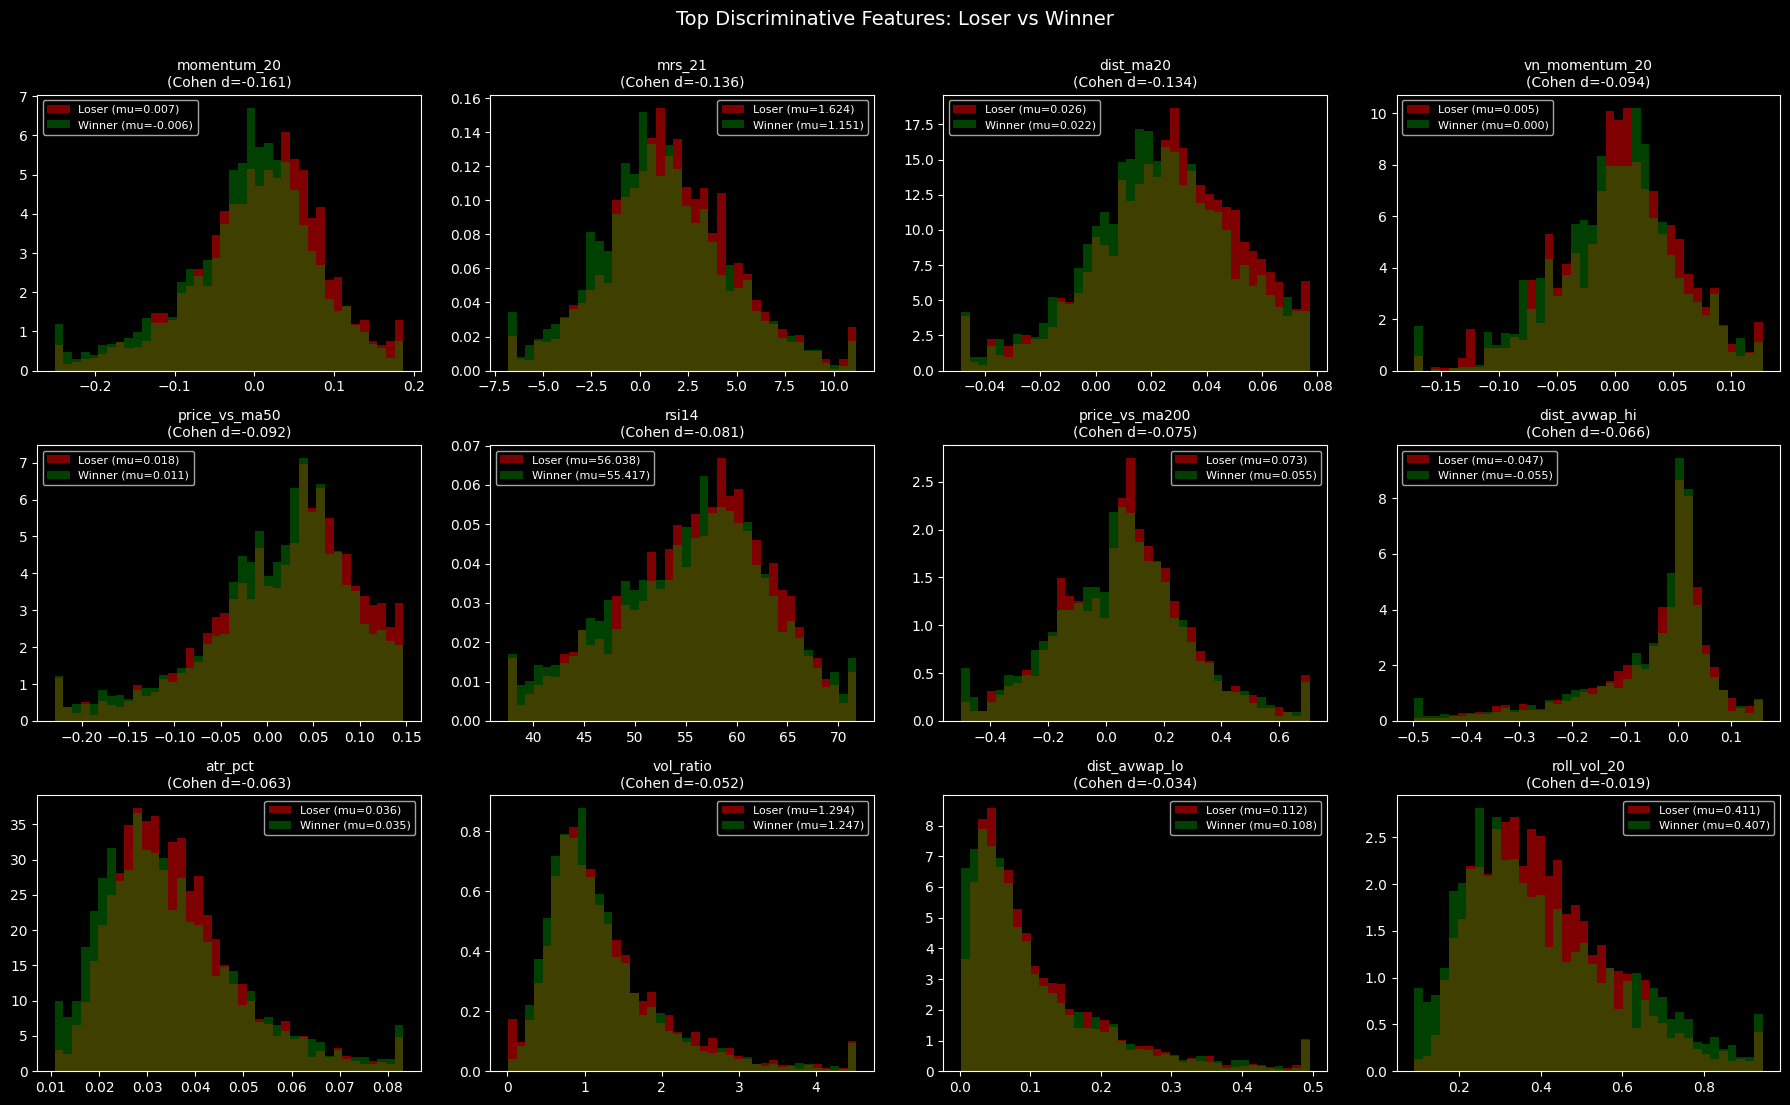

In [ ]:
top_features = discrim_df.head(12)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, feat in zip(axes.flat, top_features):
    loser_vals  = losers[feat].dropna()
    winner_vals = winners[feat].dropna()
    p1  = min(loser_vals.quantile(0.01), winner_vals.quantile(0.01))
    p99 = max(loser_vals.quantile(0.99), winner_vals.quantile(0.99))
    ax.hist(loser_vals.clip(p1, p99),  bins=40, alpha=0.5,
            label=f'Loser (mu={loser_vals.mean():.3f})',  color='red',   density=True)
    ax.hist(winner_vals.clip(p1, p99), bins=40, alpha=0.5,
            label=f'Winner (mu={winner_vals.mean():.3f})', color='green', density=True)
    d = discrim_df.set_index('feature').loc[feat, 'cohen_d']
    ax.set_title(f'{feat}\n(Cohen d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Top Discriminative Features: Loser vs Winner', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


### 2.3 Catastrophic Loss Deep Dive

Top 15 features distinguishing CATASTROPHIC losers from everything else:
       feature  loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat    ks_pvalue   mwu_pvalue
       atr_pct    0.040994     0.031266 -0.678118     0.678118 0.329298 6.786084e-74 1.989783e-89
   roll_vol_20    0.477516     0.354589 -0.668150     0.668150 0.312051 3.195702e-66 7.835226e-83
        mrs_21    2.319186     0.751949 -0.441315     0.441315 0.219325 1.292507e-32 1.013650e-37
 dist_avwap_lo    0.134527     0.088913 -0.419997     0.419997 0.276917 4.967668e-52 3.572541e-60
     dist_ma20    0.029526     0.019168 -0.373919     0.373919 0.223249 8.776699e-34 2.838800e-32
price_vs_ma200    0.090613     0.047407 -0.180487     0.180487 0.172262 3.246340e-20 3.103907e-09
vn_momentum_20   -0.002239     0.006877  0.164717     0.164717 0.110558 1.462194e-08 9.602677e-06
         rsi14   55.767148    54.620191 -0.134738     0.134738 0.096269 1.355008e-06 4.109965e-05
 price_vs_ma50    0.018242     0.009667 -0.10

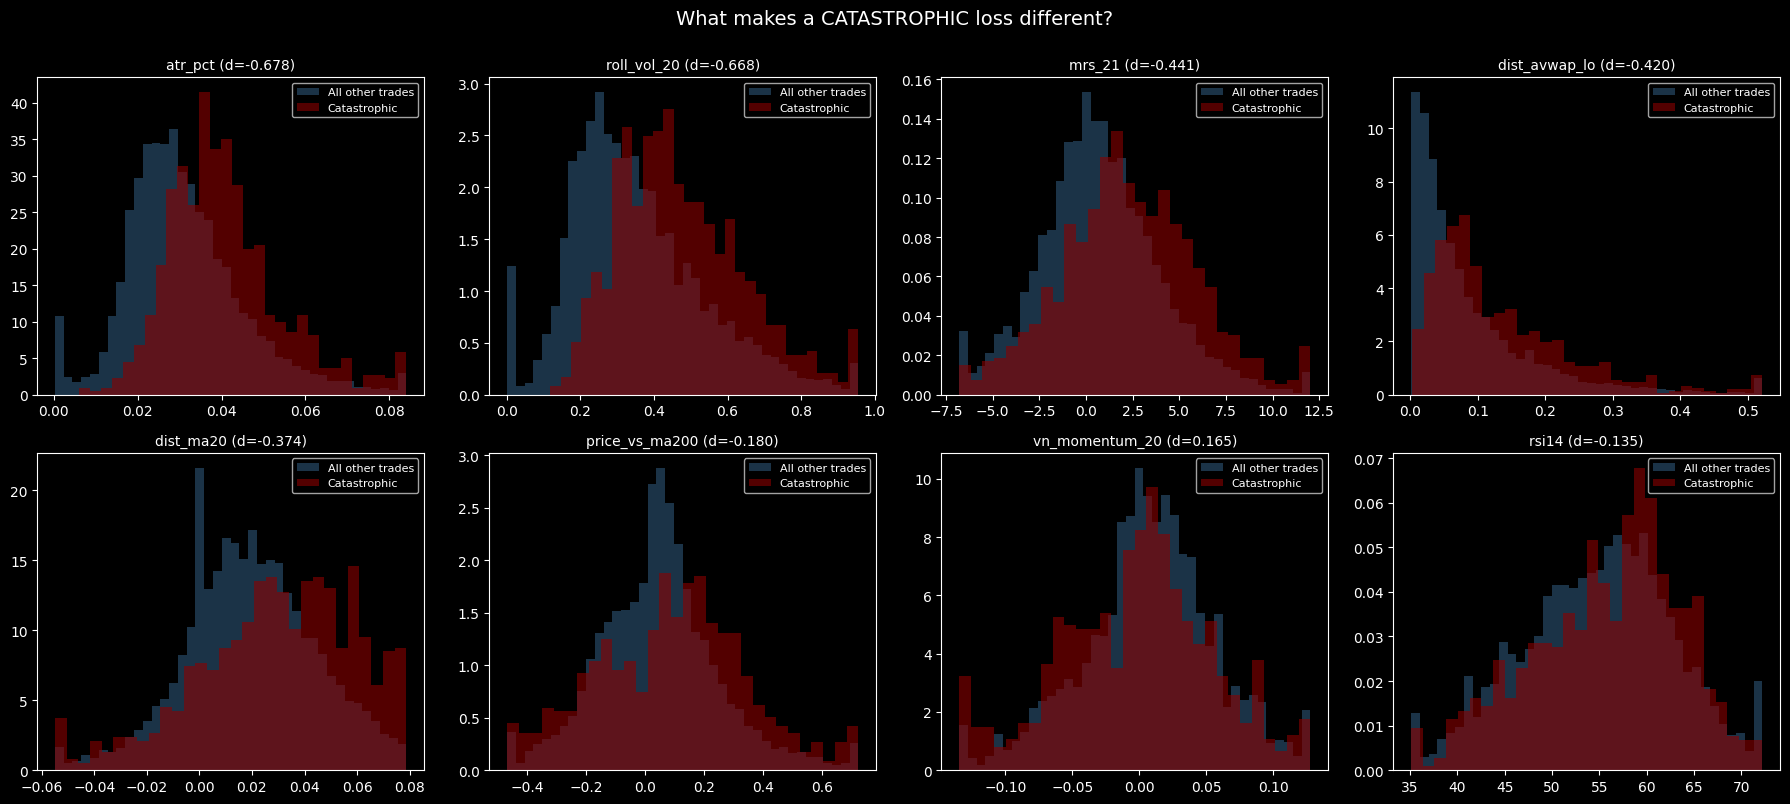

In [ ]:
catastrophic_vs_others = feature_discrimination(
    catastrophic,
    training_df[training_df['outcome'] != '1_catastrophic_loss'],
    feature_cols,
)
print('Top 15 features distinguishing CATASTROPHIC losers from everything else:')
print(catastrophic_vs_others.head(15).to_string(index=False))

top_cat_feats = catastrophic_vs_others.head(8)['feature'].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, top_cat_feats):
    cat_vals    = catastrophic[feat].dropna()
    others_vals = training_df[training_df['outcome'] != '1_catastrophic_loss'][feat].dropna()
    p1  = min(cat_vals.quantile(0.01),    others_vals.quantile(0.01))
    p99 = max(cat_vals.quantile(0.99),    others_vals.quantile(0.99))
    ax.hist(others_vals.clip(p1, p99), bins=40, alpha=0.4,
            label='All other trades', color='steelblue', density=True)
    ax.hist(cat_vals.clip(p1, p99),    bins=30, alpha=0.6,
            label='Catastrophic',     color='darkred',   density=True)
    d = catastrophic_vs_others.set_index('feature').loc[feat, 'cohen_d']
    ax.set_title(f'{feat} (d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('What makes a CATASTROPHIC loss different?', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


#### 2.3b Feature Engineering: What Predicts Catastrophic Loss?

For each top-discriminating feature, find the **threshold** that most separates
catastrophic trades from the rest.  Output: risk-ratio table + actionable entry filters.


In [ ]:
def catastrophic_risk_thresholds(df, cat_label, feature_cols, n_top=10, n_bins=20):
    """
    For each feature, sweep thresholds and find the split that maximises the
    lift in catastrophic rate (P(catastrophic | feature <= threshold) vs baseline).
    Returns a ranked DataFrame of risk-increasing conditions.
    """
    baseline_rate = (df['outcome'] == cat_label).mean()
    rows = []
    for feat in feature_cols:
        col = df[feat].dropna()
        if len(col) < 30:
            continue
        thresholds = np.percentile(col, np.linspace(10, 90, n_bins))
        best_lift, best_thresh, best_dir, best_n = 0.0, None, None, 0
        for t in thresholds:
            for direction, mask in [('low', df[feat] <= t), ('high', df[feat] > t)]:
                subset = df[mask.reindex(df.index, fill_value=False)]
                if len(subset) < 10:
                    continue
                cat_rate = (subset['outcome'] == cat_label).mean()
                lift = cat_rate / (baseline_rate + 1e-9)
                if lift > best_lift:
                    best_lift, best_thresh, best_dir, best_n = lift, t, direction, len(subset)
        if best_thresh is not None and best_lift > 1.2:
            sign = '<=' if best_dir == 'low' else '>'
            rows.append({
                'feature':        feat,
                'condition':      f'{feat} {sign} {best_thresh:.4g}',
                'direction':      best_dir,
                'threshold':      best_thresh,
                'cat_rate_in':    (df[df[feat].le(best_thresh) if best_dir == 'low' else df[feat].gt(best_thresh)]['outcome'] == cat_label).mean(),
                'cat_rate_out':   (df[~(df[feat].le(best_thresh) if best_dir == 'low' else df[feat].gt(best_thresh))]['outcome'] == cat_label).mean(),
                'lift':           best_lift,
                'n_trades':       best_n,
            })
    result = pd.DataFrame(rows).sort_values('lift', ascending=False)
    result['baseline_cat_rate'] = baseline_rate
    result['cat_rate_reduction'] = result['cat_rate_out'] - baseline_rate  # negative = filter helps
    return result


cat_thresholds = catastrophic_risk_thresholds(
    training_df, '1_catastrophic_loss', feature_cols, n_top=10, n_bins=20
)

print(f'Baseline catastrophic rate: {(training_df["outcome"]=="1_catastrophic_loss").mean():.1%}')
print(f'\nTop conditions that INCREASE catastrophic risk (lift > 1.2x):')
print(cat_thresholds[[
    'condition', 'cat_rate_in', 'cat_rate_out', 'lift', 'n_trades'
]].head(n_top := min(15, len(cat_thresholds))).to_string(index=False))

# ── Risk-reduction filters: inverse of the above ─────────────────────────────
print('\n--- Actionable entry filters (flip condition to EXCLUDE high-risk zone) ---')
for _, row in cat_thresholds.head(n_top).iterrows():
    flip_sign = '>' if row['direction'] == 'low' else '<='
    print(f"  REQUIRE {row['feature']} {flip_sign} {row['threshold']:.4g}  "
          f"→ cat rate: {row['cat_rate_in']:.1%} inside risk zone  "
          f"vs {row['cat_rate_out']:.1%} outside  "
          f"(lift {row['lift']:.2f}x, n={row['n_trades']})")


Baseline catastrophic rate: 10.0%

Top conditions that INCREASE catastrophic risk (lift > 1.2x):
                 condition  cat_rate_in  cat_rate_out     lift  n_trades
       dist_ma20 > 0.05435     0.221040      0.086608 2.209095       846
   price_vs_ma50 > 0.09972     0.216312      0.087134 2.161842       846
            mrs_21 > 5.191     0.210402      0.087791 2.102775       846
         atr_pct > 0.04651     0.191348      0.084930 1.912347      1202
      roll_vol_20 > 0.6264     0.190307      0.090025 1.901949       846
    price_vs_ma200 > 0.309     0.182033      0.090945 1.819255       846
    dist_avwap_lo > 0.1825     0.175833      0.087526 1.757294      1200
     momentum_20 > 0.08693     0.159574      0.093442 1.594802       846
vn_momentum_20 <= -0.04733     0.155574      0.090859 1.554821      1202
    dist_avwap_hi > 0.0472     0.148936      0.094625 1.488481       846
         vol_ratio > 1.912     0.129804      0.095277 1.297269      1171
             rsi14 > 63.23 

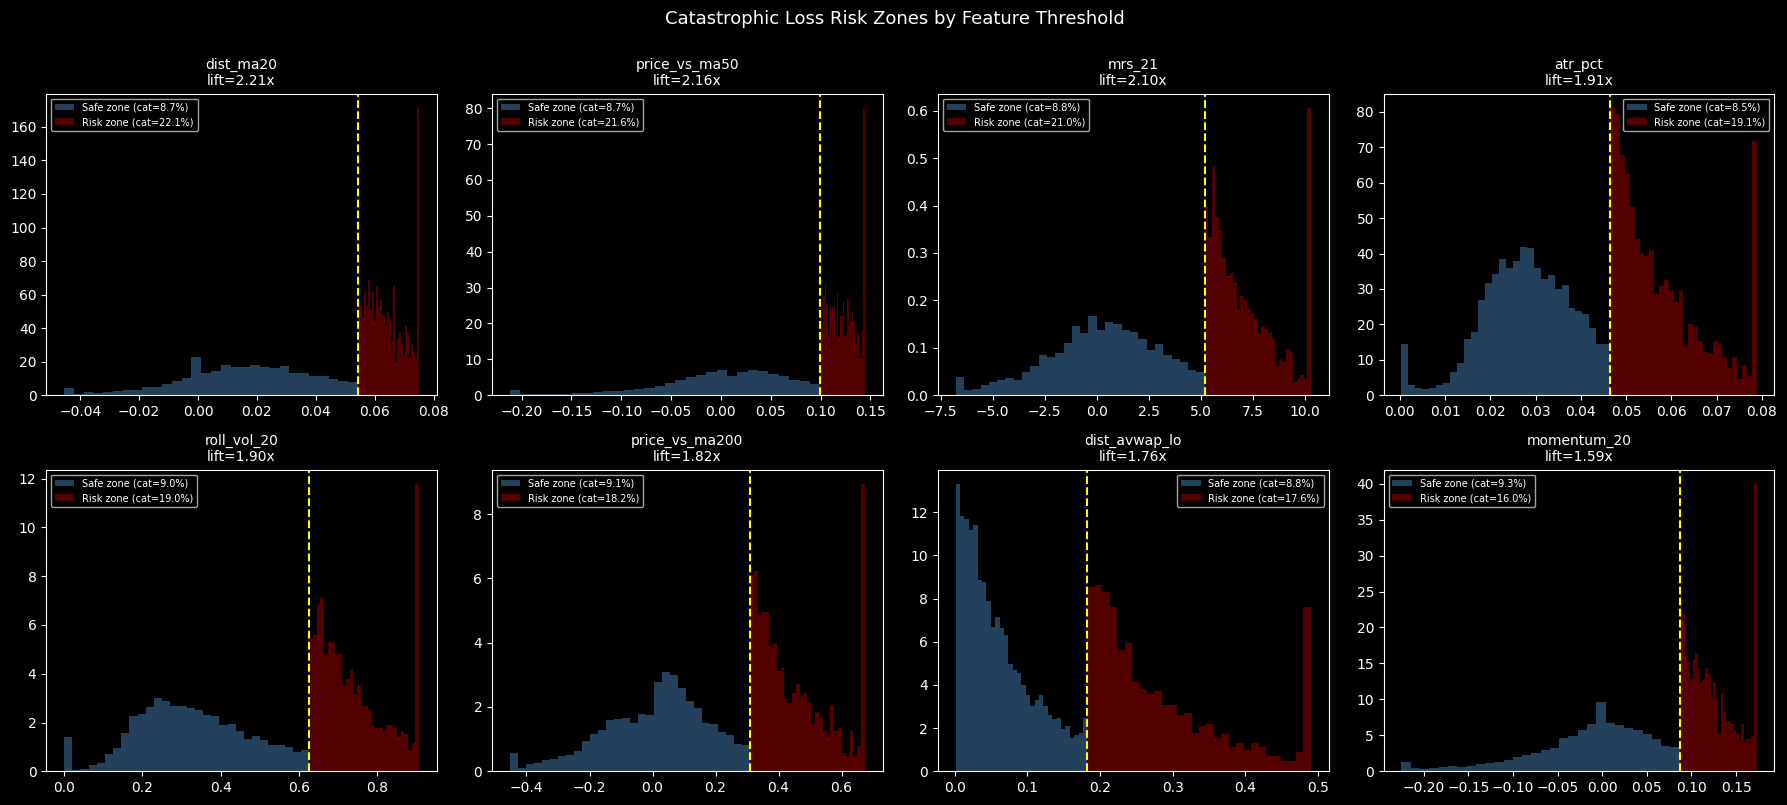

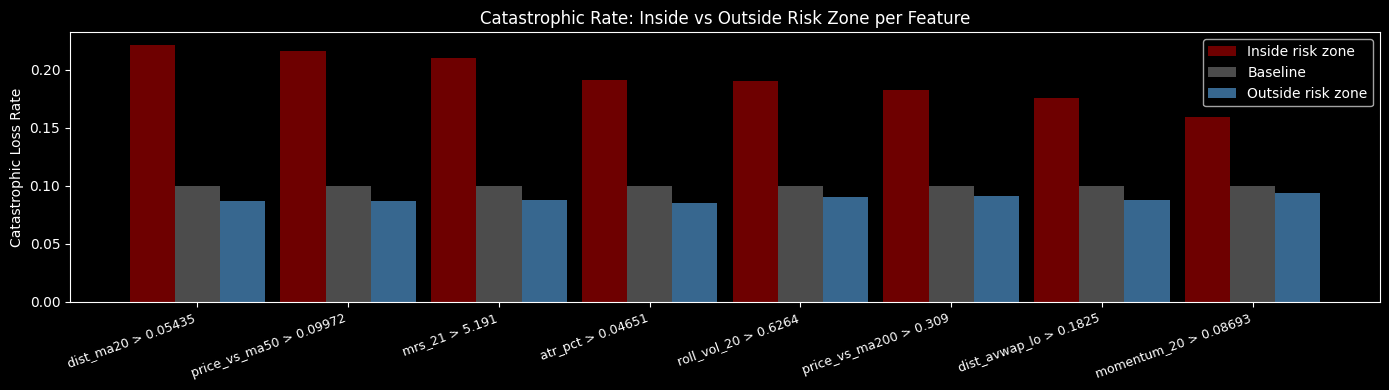

In [ ]:
# ── Visualise: top N risk-lifting conditions ─────────────────────────────────
if len(cat_thresholds) == 0:
    print('No strong threshold signals found.')
else:
    n_show   = min(8, len(cat_thresholds))
    top_rows = cat_thresholds.head(n_show).reset_index(drop=True)
    baseline = top_rows['baseline_cat_rate'].iloc[0]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, (_, row) in zip(axes.flat, top_rows.iterrows()):
        feat   = row['feature']
        thresh = row['threshold']
        dirn   = row['direction']

        col = training_df[feat].dropna()
        p1, p99 = col.quantile(0.01), col.quantile(0.99)

        inside_mask  = training_df[feat].le(thresh) if dirn == 'low' else training_df[feat].gt(thresh)
        outside_mask = ~inside_mask

        inside_vals  = training_df.loc[inside_mask.reindex(training_df.index, fill_value=False),  feat].dropna()
        outside_vals = training_df.loc[outside_mask.reindex(training_df.index, fill_value=False), feat].dropna()

        ax.hist(outside_vals.clip(p1, p99), bins=30, alpha=0.5, color='steelblue',
                label=f'Safe zone (cat={row["cat_rate_out"]:.1%})', density=True)
        ax.hist(inside_vals.clip(p1, p99),  bins=30, alpha=0.6, color='darkred',
                label=f'Risk zone (cat={row["cat_rate_in"]:.1%})',  density=True)
        ax.axvline(thresh, color='yellow', linewidth=1.5, linestyle='--')
        ax.set_title(f'{feat}\nlift={row["lift"]:.2f}x', fontsize=10)
        ax.legend(fontsize=7)

    plt.suptitle('Catastrophic Loss Risk Zones by Feature Threshold', fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()

    # Summary bar chart: cat_rate inside vs outside vs baseline
    fig, ax = plt.subplots(figsize=(14, 4))
    x = np.arange(n_show)
    w = 0.3
    ax.bar(x - w, top_rows['cat_rate_in'],  w, label='Inside risk zone',  color='darkred',   alpha=0.8)
    ax.bar(x,     top_rows['baseline_cat_rate'], w, label='Baseline',    color='gray',      alpha=0.6)
    ax.bar(x + w, top_rows['cat_rate_out'], w, label='Outside risk zone', color='steelblue', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([r['condition'] for _, r in top_rows.iterrows()], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Catastrophic Loss Rate')
    ax.set_title('Catastrophic Rate: Inside vs Outside Risk Zone per Feature')
    ax.legend()
    plt.tight_layout()
    plt.show()


### 2.4 Time & Seasonality

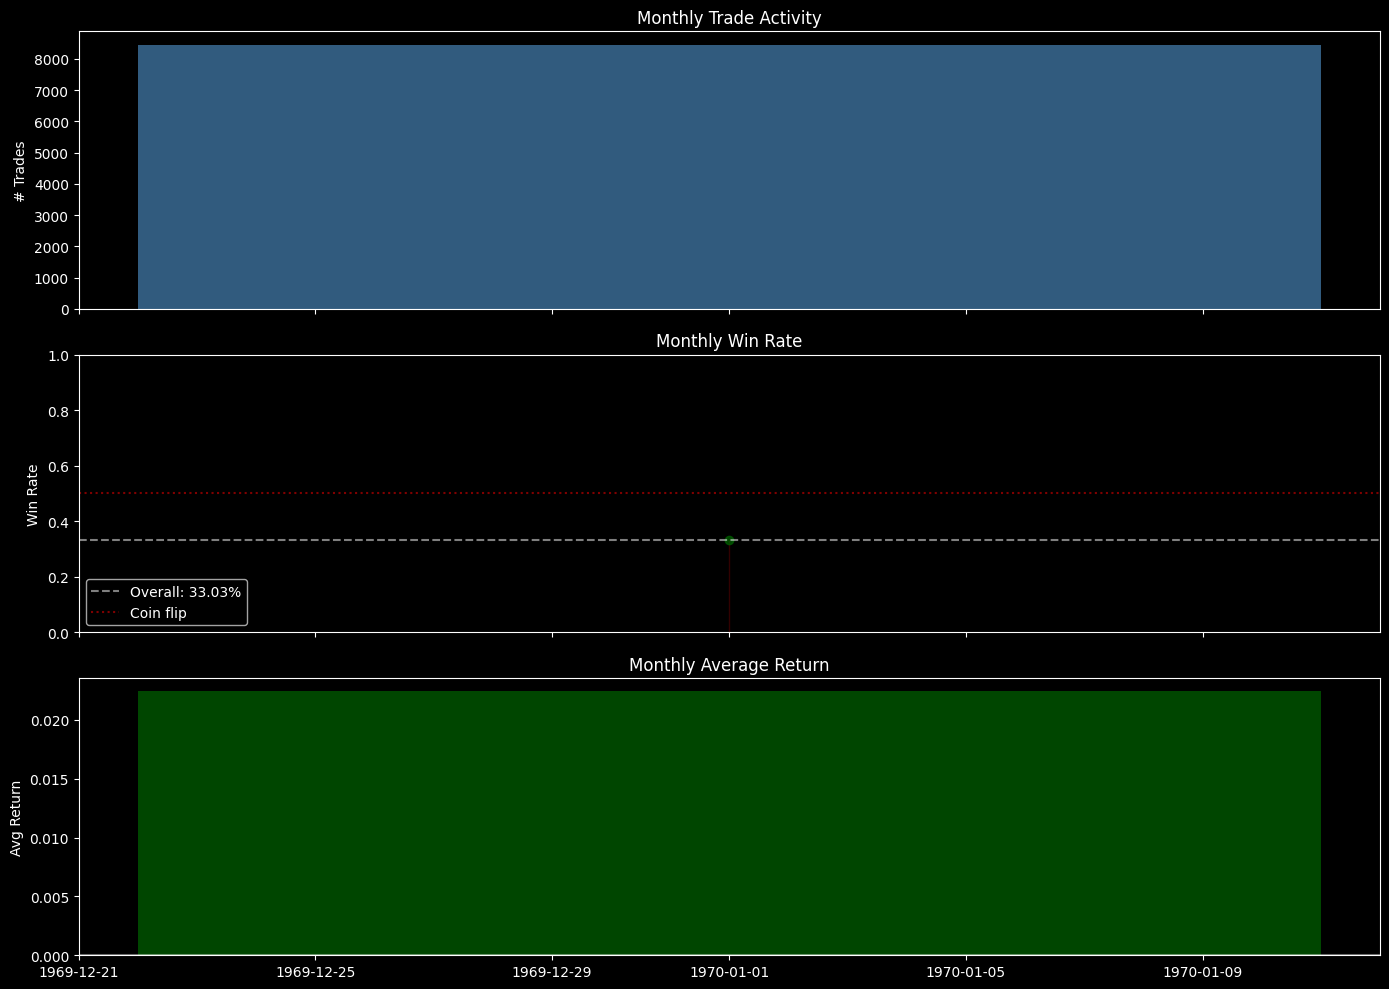

In [ ]:
training_df['year_month'] = training_df['entry_date'].dt.to_period('M')
monthly_stats = training_df.groupby('year_month').agg(
    n_trades=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
).reset_index()
monthly_stats['year_month'] = monthly_stats['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].bar(monthly_stats['year_month'], monthly_stats['n_trades'],
            width=20, color='steelblue', alpha=0.7)
axes[0].set_ylabel('# Trades')
axes[0].set_title('Monthly Trade Activity')

axes[1].plot(monthly_stats['year_month'], monthly_stats['win_rate'],
             marker='o', color='darkgreen', alpha=0.7)
axes[1].axhline(training_df['Y'].mean(), color='white', linestyle='--', alpha=0.5,
                label=f'Overall: {training_df["Y"].mean():.2%}')
axes[1].axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Coin flip')
axes[1].fill_between(monthly_stats['year_month'], 0, monthly_stats['win_rate'],
                     where=(monthly_stats['win_rate'] < 0.4), color='red', alpha=0.2)
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower left')
axes[1].set_title('Monthly Win Rate')

axes[2].bar(monthly_stats['year_month'], monthly_stats['avg_return'],
            width=20,
            color=['darkgreen' if r > 0 else 'darkred' for r in monthly_stats['avg_return']],
            alpha=0.7)
axes[2].axhline(0, color='white', alpha=0.4)
axes[2].set_ylabel('Avg Return')
axes[2].set_title('Monthly Average Return')

plt.tight_layout()
plt.show()


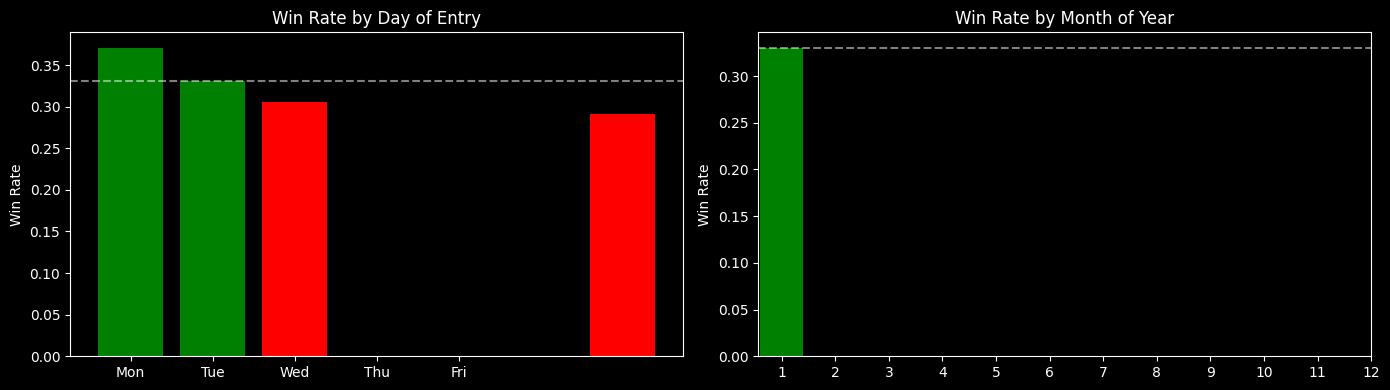

In [ ]:
training_df['dow']   = training_df['entry_date'].dt.dayofweek
training_df['month'] = training_df['entry_date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dow_stats = training_df.groupby('dow').agg(
    win_rate=('Y', 'mean'), n_trades=('Y', 'count'),
).reset_index()
overall_wr = training_df['Y'].mean()
axes[0].bar(dow_stats['dow'][:5], dow_stats['win_rate'][:5],
            color=['red' if w < overall_wr else 'green'
                   for w in dow_stats['win_rate'][:5]])
axes[0].axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
axes[0].set_ylabel('Win Rate')
axes[0].set_title('Win Rate by Day of Entry')

month_stats = training_df.groupby('month').agg(
    win_rate=('Y', 'mean'), n_trades=('Y', 'count'),
).reset_index()
axes[1].bar(month_stats['month'], month_stats['win_rate'],
            color=['red' if w < overall_wr else 'green'
                   for w in month_stats['win_rate']])
axes[1].axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
axes[1].set_xticks(range(1, 13))
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate by Month of Year')

plt.tight_layout()
plt.show()


### 2.5 Symbol Hotspots

Worst 10 symbols:
symbol  n_trades  win_rate  avg_return  median_return  sum_return
   DXS        17  0.117647   -0.018998      -0.016949   -0.322961
   CII        43  0.232558   -0.012948      -0.025507   -0.556748
   HHV        65  0.092308   -0.012730       0.000000   -0.827439
   DVM        17  0.176471   -0.011637      -0.028571   -0.197837
   VRE        62  0.193548   -0.009953      -0.022936   -0.617078
   PLX        52  0.211538   -0.009559      -0.020403   -0.497070
   TCM        44  0.204545   -0.009035      -0.026875   -0.397531
   VHC        56  0.285714   -0.006890      -0.013569   -0.385830
   PAN        40  0.275000   -0.005505      -0.021347   -0.220195
   NHH        41  0.243902   -0.004750      -0.019324   -0.194744

Best 10 symbols:
symbol  n_trades  win_rate  avg_return  median_return  sum_return
   DRI        34  0.411765    0.067796      -0.006686    2.305072
   HUT        29  0.310345    0.068433      -0.017897    1.984554
   YEG        18  0.333333    0.069468  

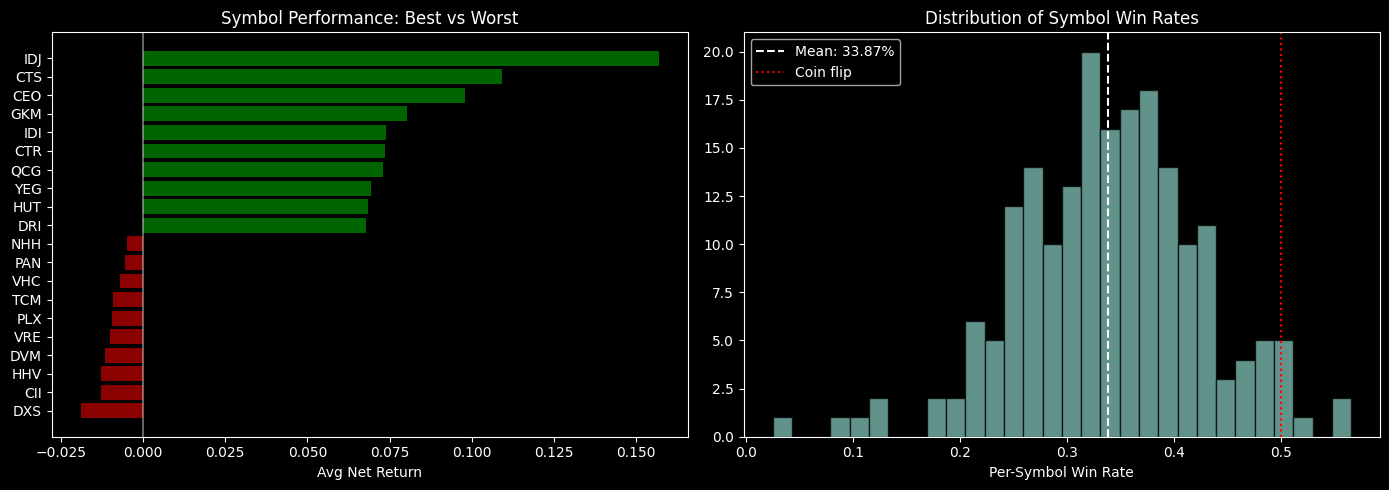


Chronic loser symbols (win rate < 35%, >=20 trades):
symbol  n_trades  win_rate  avg_return
   CII        43  0.232558   -0.012948
   HHV        65  0.092308   -0.012730
   VRE        62  0.193548   -0.009953
   PLX        52  0.211538   -0.009559
   TCM        44  0.204545   -0.009035
   VHC        56  0.285714   -0.006890
   PAN        40  0.275000   -0.005505
   NHH        41  0.243902   -0.004750
   EIB        38  0.263158   -0.004683
   LSS        32  0.250000   -0.004490
   HAG        35  0.257143   -0.003017
   VHM        49  0.224490   -0.002439
   VPI        57  0.245614   -0.002419
   PLC        37  0.216216   -0.002046
   VJC        53  0.264151   -0.001659
   VCG        52  0.173077   -0.001355
   APH        26  0.307692   -0.001007
   FCN        40  0.275000    0.000076
   SAB        54  0.296296    0.000832
   KDH        72  0.291667    0.001046
   TPB        49  0.244898    0.001903
   MWG        72  0.305556    0.002632
   QTP        38  0.289474    0.002787
   AAA    

In [ ]:
symbol_stats = training_df.groupby('symbol').agg(
    n_trades=('Y', 'count'),
    win_rate=('Y', 'mean'),
    avg_return=('net_return', 'mean'),
    median_return=('net_return', 'median'),
    sum_return=('net_return', 'sum'),
).reset_index()
symbol_stats = symbol_stats[symbol_stats['n_trades'] >= 10]
symbol_stats = symbol_stats.sort_values('avg_return')

print('Worst 10 symbols:')
print(symbol_stats.head(10).to_string(index=False))
print('\nBest 10 symbols:')
print(symbol_stats.tail(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10_worst = symbol_stats.head(10)
top10_best  = symbol_stats.tail(10)
combined = pd.concat([top10_worst, top10_best])
colors = ['darkred'] * 10 + ['darkgreen'] * 10
axes[0].barh(combined['symbol'], combined['avg_return'], color=colors)
axes[0].axvline(0, color='white', alpha=0.4)
axes[0].set_xlabel('Avg Net Return')
axes[0].set_title('Symbol Performance: Best vs Worst')

axes[1].hist(symbol_stats['win_rate'], bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(symbol_stats['win_rate'].mean(), color='white', linestyle='--',
                label=f'Mean: {symbol_stats["win_rate"].mean():.2%}')
axes[1].axvline(0.5, color='red', linestyle=':', label='Coin flip')
axes[1].set_xlabel('Per-Symbol Win Rate')
axes[1].set_title('Distribution of Symbol Win Rates')
axes[1].legend()

plt.tight_layout()
plt.show()

chronic_losers = symbol_stats[
    (symbol_stats['win_rate'] < 0.35) & (symbol_stats['n_trades'] >= 20)
]
print(f'\nChronic loser symbols (win rate < 35%, >=20 trades):')
print(chronic_losers[['symbol', 'n_trades', 'win_rate', 'avg_return']].to_string(index=False))


### 2.6 MFE / MAE Path Analysis

Requires `stocks` panel in scope (run Section 1, or load it below).


In [ ]:
# Load stocks panel (close prices) for path analysis
if 'stocks' not in dir():
    local_file = 'stocks_data_latest.h5'
    print(f'Loading stocks from {local_file} ...')
    with pd.HDFStore(local_file, mode='r') as store:
        stocks = store['stocks']
    print(f'Loaded: {stocks.shape}')

cl = stocks['close']

# ── Hard diagnostics: see exactly what's in the data ─────────────────────────
print('=== DATA DIAGNOSTICS ===')
print(f'training_df columns     : {list(training_df.columns)}')
print(f'entry_date dtype         : {training_df["entry_date"].dtype}')
print(f'exit_date  dtype         : {training_df["exit_date"].dtype}')
print(f'entry_bar present        : {"entry_bar" in training_df.columns}')
print(f'exit_bar  present        : {"exit_bar"  in training_df.columns}')
print()
print('First 5 trades (dates + return):')
show_cols = [c for c in ['symbol','entry_date','exit_date','entry_bar','exit_bar','net_return']
             if c in training_df.columns]
print(training_df[show_cols].head(5).to_string(index=False))
print()
print(f'close panel index range  : {cl.index[0]} -> {cl.index[-1]}')
print(f'close panel index dtype  : {cl.index.dtype}')
print(f'close panel n symbols    : {len(cl.columns)}')
sample_sym = training_df['symbol'].iloc[0]
print(f'Sample symbol lookup test: {sample_sym} in cl.columns = {sample_sym in cl.columns}')

# date alignment check
_t0 = pd.Timestamp(training_df['entry_date'].iloc[0]).tz_localize(None)
_slice = cl[sample_sym].loc[_t0 - pd.Timedelta(days=2): _t0 + pd.Timedelta(days=2)]
print(f'Date slice around first entry ({_t0.date()}): {len(_slice)} bars found')
print(_slice)
print('========================')


def compute_path_excursions(trades_df, close_panel):
    """
    Compute MFE/MAE.  Priority order for path lookup:
    1. entry_bar / exit_bar (integer positions) — most reliable
    2. entry_date / exit_date date lookup — fallback
    3. entry price match forward scan — last resort when dates collapsed
    """
    out    = trades_df.copy()
    n_bars = len(close_panel)
    use_bar_idx = ('entry_bar' in trades_df.columns and 'exit_bar' in trades_df.columns)

    mfe_list, mae_list, hold_list = [], [], []

    for _, trade in trades_df.iterrows():
        sym = trade['symbol']
        if sym not in close_panel.columns:
            mfe_list.append(np.nan); mae_list.append(np.nan); hold_list.append(np.nan)
            continue
        try:
            series = close_panel[sym].dropna()

            if use_bar_idx:
                b0 = int(trade['entry_bar'])
                b1 = int(trade['exit_bar'])
                if b1 <= b0:
                    b1 = min(b0 + 1, n_bars - 1)
                path = close_panel[sym].iloc[b0: b1 + 1].dropna()
                hold = b1 - b0
            else:
                # date-based: strip tz and normalize
                t0 = pd.Timestamp(trade['entry_date']).tz_localize(None).normalize()
                t1 = pd.Timestamp(trade['exit_date']).tz_localize(None).normalize()
                path = series.loc[t0:t1]
                hold = (t1 - t0).days

                # fallback: dates collapsed → find entry bar by matching date, scan forward
                if len(path) < 2:
                    candidates = series.index[series.index >= t0]
                    if len(candidates) == 0:
                        mfe_list.append(np.nan); mae_list.append(np.nan); hold_list.append(0)
                        continue
                    b0 = series.index.get_loc(candidates[0])
                    # estimate hold from entry/exit prices: scan forward until price matches exit
                    ep   = float(trade.get('Entry Price', series.iloc[b0]))
                    xp   = float(trade.get('Exit Price',  ep))
                    ret  = float(trade['net_return'])
                    # duration proxy: search for when return is realised (capped at 60 bars)
                    fwd  = series.iloc[b0: b0 + 61]
                    if ep > 0 and len(fwd) > 1:
                        # find first bar where cumulative return >= realized return
                        cum_ret = fwd / ep - 1
                        if ret >= 0:
                            hit = np.where(cum_ret >= ret)[0]
                        else:
                            hit = np.where(cum_ret <= ret)[0]
                        b1_local = int(hit[0]) if len(hit) else len(fwd) - 1
                        path = fwd.iloc[: b1_local + 1]
                        hold = b1_local
                    else:
                        mfe_list.append(np.nan); mae_list.append(np.nan); hold_list.append(0)
                        continue

            if len(path) < 2:
                mfe_list.append(np.nan); mae_list.append(np.nan); hold_list.append(0)
                continue

            ep = path.iloc[0]
            mfe_list.append(path.max() / ep - 1)
            mae_list.append(path.min() / ep - 1)
            hold_list.append(hold)
        except Exception:
            mfe_list.append(np.nan); mae_list.append(np.nan); hold_list.append(np.nan)

    out['mfe']          = mfe_list
    out['mae']          = mae_list
    out['holding_days'] = hold_list
    out['efficiency']   = out['net_return'] / out['mfe'].replace(0, np.nan)
    return out


print('Computing MFE/MAE ...')
training_df = compute_path_excursions(training_df, cl)
losers  = training_df[training_df['outcome'].isin(['1_catastrophic_loss', '2_medium_loss'])].copy()
winners = training_df[training_df['outcome'].isin(['4_medium_win', '5_big_win'])].copy()
print(training_df[['mfe', 'mae', 'efficiency', 'holding_days']].describe().round(3))


Computing MFE/MAE ...
       mfe  mae  efficiency  holding_days
count  0.0  0.0         0.0        8455.0
mean   NaN  NaN         NaN           0.0
std    NaN  NaN         NaN           0.0
min    NaN  NaN         NaN           0.0
25%    NaN  NaN         NaN           0.0
50%    NaN  NaN         NaN           0.0
75%    NaN  NaN         NaN           0.0
max    NaN  NaN         NaN           0.0


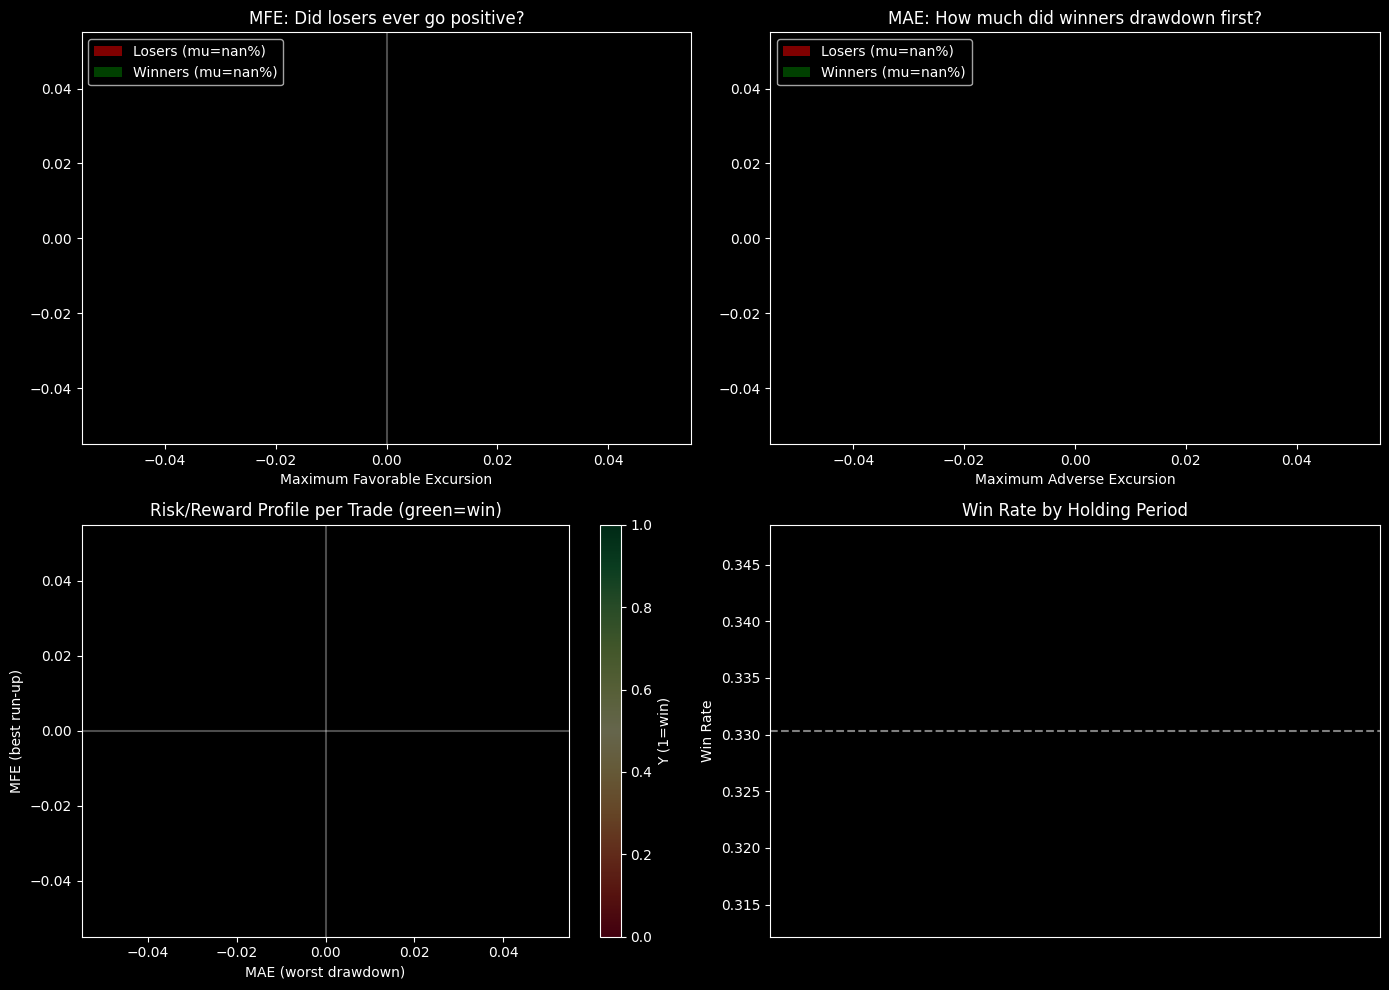

Losers MFE > 0 : 0.0% (were once profitable)
Winners MAE < -2%: 0.0% (drew down >2% first)
Avg efficiency: nan


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(losers['mfe'].dropna().clip(-0.05, 0.20),  bins=40, alpha=0.5,
        label=f'Losers (mu={losers["mfe"].mean():.2%})',   color='red',   density=True)
ax.hist(winners['mfe'].dropna().clip(-0.05, 0.20), bins=40, alpha=0.5,
        label=f'Winners (mu={winners["mfe"].mean():.2%})', color='green', density=True)
ax.set_xlabel('Maximum Favorable Excursion')
ax.set_title('MFE: Did losers ever go positive?')
ax.legend()
ax.axvline(0, color='white', alpha=0.3)

ax = axes[0, 1]
ax.hist(losers['mae'].dropna().clip(-0.20, 0.05),  bins=40, alpha=0.5,
        label=f'Losers (mu={losers["mae"].mean():.2%})',   color='red',   density=True)
ax.hist(winners['mae'].dropna().clip(-0.20, 0.05), bins=40, alpha=0.5,
        label=f'Winners (mu={winners["mae"].mean():.2%})', color='green', density=True)
ax.set_xlabel('Maximum Adverse Excursion')
ax.set_title('MAE: How much did winners drawdown first?')
ax.legend()

ax = axes[1, 0]
_pool = training_df.dropna(subset=['mfe', 'mae'])
sample = _pool.sample(min(2000, len(_pool)))
sc = ax.scatter(sample['mae'], sample['mfe'], c=sample['Y'],
                cmap='RdYlGn', alpha=0.4, s=10)
ax.axhline(0, color='white', alpha=0.3)
ax.axvline(0, color='white', alpha=0.3)
ax.set_xlabel('MAE (worst drawdown)')
ax.set_ylabel('MFE (best run-up)')
ax.set_title('Risk/Reward Profile per Trade (green=win)')
plt.colorbar(sc, ax=ax, label='Y (1=win)')

ax = axes[1, 1]
hold_bins   = [0, 5, 10, 20, 40, 80, 200]
hold_labels = ['1-5d', '6-10d', '11-20d', '21-40d', '41-80d', '80d+']
training_df['hold_bin'] = pd.cut(training_df['holding_days'], bins=hold_bins, labels=hold_labels)
hold_stats = training_df.groupby('hold_bin', observed=True).agg(
    win_rate=('Y', 'mean'), n=('Y', 'count'),
)
ax.bar(range(len(hold_stats)), hold_stats['win_rate'],
       color=['red' if w < training_df['Y'].mean() else 'green'
              for w in hold_stats['win_rate']])
ax.axhline(training_df['Y'].mean(), color='white', linestyle='--', alpha=0.5)
ax.set_xticks(range(len(hold_stats)))
ax.set_xticklabels(hold_stats.index)
ax.set_ylabel('Win Rate')
ax.set_title('Win Rate by Holding Period')
for i, n in enumerate(hold_stats['n']):
    ax.text(i, 0.05, f'n={n}', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Losers MFE > 0 : {(losers["mfe"] > 0).mean():.1%} (were once profitable)')
print(f'Winners MAE < -2%: {(winners["mae"] < -0.02).mean():.1%} (drew down >2% first)')
print(f'Avg efficiency: {training_df["efficiency"].median():.2f}')


### 2.7 VNINDEX Regime Diagnostics

In [ ]:
vnindex = stocks['close']['VNINDEX'].dropna()

# ── Diagnostics: check index/dtype alignment ─────────────────────────────────
_t0 = training_df['entry_date'].iloc[0]
print(f'entry_date dtype : {training_df["entry_date"].dtype}')
print(f'entry_date sample: {_t0!r}  (type={type(_t0).__name__})')
print(f'vnindex.index dtype  : {vnindex.index.dtype}')
print(f'vnindex.index sample : {vnindex.index[0]!r}')

# ── Normalise entry_date: strip timezone, keep date only ─────────────────────
_dates = pd.to_datetime(training_df['entry_date']).dt.tz_localize(None).dt.normalize()
_vn_idx = vnindex.index
if hasattr(_vn_idx, 'tz') and _vn_idx.tz is not None:
    vnindex = vnindex.tz_localize(None)

# Verify one lookup works before looping
_test = vnindex.loc[:_dates.iloc[-1]]
print(f'\nTest lookup for last entry {_dates.iloc[-1].date()}: {len(_test)} bars found')


def vnindex_state_at(t):
    t = pd.Timestamp(t).tz_localize(None).normalize()
    vix_past = vnindex.loc[:t]
    if len(vix_past) < 200:
        return {}
    return {
        'vnindex_ret_5d':       vix_past.iloc[-1] / vix_past.iloc[-5]   - 1,
        'vnindex_ret_20d':      vix_past.iloc[-1] / vix_past.iloc[-20]  - 1,
        'vnindex_above_ema50':  int(vix_past.iloc[-1] > vix_past.tail(50).mean()),
        'vnindex_above_ema200': int(vix_past.iloc[-1] > vix_past.tail(200).mean()),
        'vnindex_drawdown':     vix_past.iloc[-1] / vix_past.tail(252).max() - 1,
        'vnindex_vol_20d':      vix_past.pct_change().tail(20).std(),
    }


print('Computing VNINDEX context for each trade entry...')
vix_context_list = []
_first_err = None
for t in _dates:
    try:
        vix_context_list.append(vnindex_state_at(t))
    except Exception as e:
        if _first_err is None:
            _first_err = (t, repr(e))
        vix_context_list.append({})

if _first_err:
    print(f'WARNING: first error at {_first_err[0]}: {_first_err[1]}')

vix_context = pd.DataFrame(vix_context_list, index=training_df.index)
print(f'vix_context columns: {list(vix_context.columns)}')
print(f'non-null rows      : {vix_context.notna().any(axis=1).sum()} / {len(vix_context)}')

# Drop duplicate columns if cell is re-run
new_cols = [c for c in vix_context.columns if c not in training_df.columns]
training_df = pd.concat([training_df, vix_context[new_cols]], axis=1)

_regime_cols = ['vnindex_above_ema50', 'vnindex_above_ema200']
if all(c in training_df.columns for c in _regime_cols):
    print('\nTrade outcomes by VNINDEX trend regime:')
    print(training_df.groupby(_regime_cols).agg(
        n=('Y', 'count'),
        win_rate=('Y', 'mean'),
        avg_return=('net_return', 'mean'),
    ).round(4))
else:
    print('WARNING: VNINDEX regime columns missing.')
    print(f'  Available vix_context columns: {list(vix_context.columns)}')


entry_date dtype : datetime64[ns]
entry_date sample: Timestamp('1970-01-18 06:48:57.600000')  (type=Timestamp)
vnindex.index dtype  : datetime64[us]
vnindex.index sample : Timestamp('2016-05-06 00:00:00')

Test lookup for last entry 1970-01-21: 0 bars found
Computing VNINDEX context for each trade entry...
vix_context columns: []
non-null rows      : 0 / 8455
  Available vix_context columns: []


In [ ]:
_required = ['vnindex_ret_20d', 'vnindex_drawdown', 'vnindex_vol_20d', 'vnindex_above_ema200']
_missing   = [c for c in _required if c not in training_df.columns]
if _missing:
    print(f'Skipping VNINDEX regime plots — missing columns: {_missing}')
    print('Run cell 25 first (VNINDEX context computation).')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    overall_wr = training_df['Y'].mean()

    ax = axes[0, 0]
    try:
        ret_bins = pd.qcut(training_df['vnindex_ret_20d'].dropna(), 5,
                        labels=['Bottom 20%', '20-40%', '40-60%', '60-80%', 'Top 20%'])
        if ret_bins is not None:
            training_df['vix_ret_bin'] = ret_bins
        bin_stats = training_df.groupby('vix_ret_bin', observed=True).agg(
            win_rate=('Y', 'mean'), n=('Y', 'count'),
        )
        ax.bar(range(len(bin_stats)), bin_stats['win_rate'],
               color=['darkred', 'red', 'gray', 'green', 'darkgreen'])
        ax.axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(bin_stats)))
        ax.set_xticklabels(bin_stats.index, rotation=15)
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate by VNINDEX 20d Return at Entry')
    except Exception as e:
        ax.set_title(f'vnindex_ret_20d: {e}')

    ax = axes[0, 1]
    try:
        dd_bins = pd.qcut(training_df['vnindex_drawdown'].dropna(), 5)
        if dd_bins is not None:
            training_df['vix_dd_bin'] = dd_bins
        dd_stats = training_df.groupby('vix_dd_bin', observed=True).agg(
            win_rate=('Y', 'mean'), n=('Y', 'count'),
        )
        ax.bar(range(len(dd_stats)), dd_stats['win_rate'],
               color=['darkred', 'red', 'gray', 'green', 'darkgreen'])
        ax.axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(dd_stats)))
        ax.set_xticklabels([f'{b.left:.1%}-{b.right:.1%}' for b in dd_stats.index], rotation=15)
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate by VNINDEX Drawdown at Entry')
    except Exception as e:
        ax.set_title(f'vnindex_drawdown: {e}')

    ax = axes[1, 0]
    try:
        vol_bins = pd.qcut(training_df['vnindex_vol_20d'].dropna(), 5)
        if vol_bins is not None:
            training_df['vix_vol_bin'] = vol_bins
        vol_stats = training_df.groupby('vix_vol_bin', observed=True).agg(
            win_rate=('Y', 'mean'), n=('Y', 'count'),
        )
        ax.bar(range(len(vol_stats)), vol_stats['win_rate'],
               color=['darkgreen', 'green', 'gray', 'red', 'darkred'])
        ax.axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(vol_stats)))
        ax.set_xticklabels([f'{b.left:.3f}-{b.right:.3f}' for b in vol_stats.index],
                           rotation=15, fontsize=8)
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate by VNINDEX Realized Volatility')
    except Exception as e:
        ax.set_title(f'vnindex_vol_20d: {e}')

    ax = axes[1, 1]
    filter_stats = training_df.groupby('vnindex_above_ema200').agg(
        n=('Y', 'count'), win_rate=('Y', 'mean'), avg_return=('net_return', 'mean'),
    )
    filter_stats.index = ['Bear (below EMA200)', 'Bull (above EMA200)']
    ax.bar(range(2), filter_stats['win_rate'], color=['red', 'green'])
    ax.axhline(overall_wr, color='white', linestyle='--', alpha=0.5)
    ax.set_xticks(range(2))
    ax.set_xticklabels(filter_stats.index)
    ax.set_ylabel('Win Rate')
    ax.set_title('VNINDEX Trend Filter (EMA200)')
    for i, (idx, row) in enumerate(filter_stats.iterrows()):
        ax.text(i, 0.05, f'n={row["n"]}\nret={row["avg_return"]:.2%}',
                ha='center', color='white', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()


Skipping VNINDEX regime plots — missing columns: ['vnindex_ret_20d', 'vnindex_drawdown', 'vnindex_vol_20d', 'vnindex_above_ema200']
Run cell 25 first (VNINDEX context computation).


### 2.8 Feature Engineering Candidates

Run this cell **after** completing the analyses above.
It builds a ranked list of new features worth engineering,
grounded in what the data actually showed.


In [ ]:
suggestions = []

# 1. VNINDEX trend regime
if 'vnindex_above_ema200' in training_df.columns:
    bear_wr = training_df[training_df['vnindex_above_ema200'] == 0]['Y'].mean()
    bull_wr = training_df[training_df['vnindex_above_ema200'] == 1]['Y'].mean()
    if abs(bull_wr - bear_wr) > 0.05:
        suggestions.append({
            'priority': 1,
            'name': 'vnindex_trend_regime',
            'reason': f'Bull {bull_wr:.1%} vs Bear {bear_wr:.1%} = delta {abs(bull_wr - bear_wr):.1%}',
            'idea': 'Gate entries on vnindex_above_ema50/200; use as ML feature',
        })

# 2. VNINDEX volatility regime
if 'vix_vol_bin' in training_df.columns:
    vol_stats_check = training_df.groupby('vix_vol_bin', observed=True)['Y'].mean()
    if vol_stats_check.max() - vol_stats_check.min() > 0.05:
        suggestions.append({
            'priority': 1,
            'name': 'vnindex_vol_regime',
            'reason': f'Win rate spans {vol_stats_check.min():.1%}-{vol_stats_check.max():.1%}',
            'idea': 'Add vnindex_vol_20d and vol z-score as features; reduce size in high-vol regime',
        })

# 3. Chronic loser symbols
if 'symbol_stats' in dir() and 'chronic_losers' in dir() and len(chronic_losers) > 0:
    suggestions.append({
        'priority': 2,
        'name': 'symbol_blacklist',
        'reason': f'{len(chronic_losers)} symbols with win rate < 35% and >=20 trades: {list(chronic_losers["symbol"])}',
        'idea': 'Add per-symbol rolling win rate as feature; consider blacklisting chronic losers',
    })

# 4. MFE/MAE insights
if 'mfe' in training_df.columns:
    loser_mfe_pct = (losers['mfe'] > 0).mean()
    if loser_mfe_pct > 0.3:
        suggestions.append({
            'priority': 2,
            'name': 'trailing_exit_tighter',
            'reason': f'{loser_mfe_pct:.1%} of losers were once profitable — exits too loose',
            'idea': 'Add MFE-based trailing stop (lock in 50% of MFE once trade reaches +3%)',
        })
    avg_eff = training_df['efficiency'].median()
    if avg_eff < 0.5:
        suggestions.append({
            'priority': 2,
            'name': 'capture_efficiency',
            'reason': f'Median efficiency {avg_eff:.2f} — giving back >50% of best move',
            'idea': 'Consider time-based exit (max 20d) or partial profit at 50% of MFE',
        })

# 5. Top discriminative features from univariate analysis
if 'discrim_df' in dir() and len(discrim_df) > 0:
    for _, row in discrim_df.head(5).iterrows():
        if abs(row['cohen_d']) > 0.2:
            suggestions.append({
                'priority': 3,
                'name': f'feature_{row["feature"]}',
                'reason': f'Cohen d={row["cohen_d"]:.3f}, KS={row["ks_stat"]:.3f}, winner={row["winner_mean"]:.4f} vs loser={row["loser_mean"]:.4f}',
                'idea': f'Include {row["feature"]} in ML features; possibly add threshold as entry filter',
            })

suggestions.sort(key=lambda x: x['priority'])

if not suggestions:
    print('No strong signals found — run cells 25-26 (VNINDEX regime) and cells 22-23 (MFE/MAE) first.')
else:
    print(f'Generated {len(suggestions)} feature engineering suggestions:\n')
    for i, s in enumerate(suggestions, 1):
        print(f'[P{s["priority"]}] {i}. {s["name"]}')
        print(f'   Why: {s["reason"]}')
        print(f'   How: {s["idea"]}')
        print()


Generated 1 feature engineering suggestions:

[P2] 1. symbol_blacklist
   Why: 100 symbols with win rate < 35% and >=20 trades: ['CII', 'HHV', 'VRE', 'PLX', 'TCM', 'VHC', 'PAN', 'NHH', 'EIB', 'LSS', 'HAG', 'VHM', 'VPI', 'PLC', 'VJC', 'VCG', 'APH', 'FCN', 'SAB', 'KDH', 'TPB', 'MWG', 'QTP', 'AAA', 'SJS', 'CTD', 'VNM', 'BID', 'L18', 'MSN', 'CTI', 'BWE', 'KBC', 'GMD', 'ACB', 'CNG', 'DPR', 'MSR', 'SSB', 'AGG', 'SMC', 'KSV', 'BVH', 'SHB', 'HPX', 'BMP', 'POW', 'NLG', 'VPG', 'HDB', 'TNG', 'VGI', 'TV2', 'PVB', 'KHG', 'HVN', 'STB', 'BCM', 'GEX', 'DHC', 'VGS', 'SBT', 'ACV', 'PVC', 'SKG', 'HAH', 'VGC', 'TCH', 'VPB', 'PAC', 'DTD', 'VC3', 'IDC', 'KDC', 'GEG', 'MSH', 'PVP', 'DGC', 'PVD', 'VOS', 'NKG', 'LAS', 'DPM', 'DIG', 'FTS', 'DBC', 'HDC', 'CSV', 'DCM', 'NVL', 'ELC', 'VGT', 'ORS', 'BVS', 'ADS', 'CMG', 'VC7', 'BSR', 'HUT', 'CEO']
   How: Add per-symbol rolling win rate as feature; consider blacklisting chronic losers

